In [1]:
# This cell is removed with the tag: "remove-input"
# As such, it will not be shown in documentation

import warnings
warnings.filterwarnings('ignore')


(Tutorial_Unwrap)=
# Unwrap

*Unwrapping coordinates across periodic boundaries to restore spatial continuity.*

The function {func}`molsysmt.pbc.unwrap` reconstructs continuous coordinates across structural ensembles by removing periodic jump discontinuities.

:::{versionadded} 1.0.0
:::

:::{admonition} API documentation
:class: dropdown

Follow this link for a detailed description of the input arguments, raised errors, and returned objects of this function: {func}`molsysmt.pbc.unwrap`.
:::


## Basic usage

Let's demonstrate unwrapping on an ensemble with periodic boundary crossing:


In [2]:
import molsysmt as msm
import numpy as np
import matplotlib.pyplot as plt


In [3]:
molsys = msm.convert(msm.systems['two LJ particles']['traj_two_lj_particles.trjpk'], to_form='molsysmt.StructuresDict')


:::{note} Demo Systems Catalog
:class: dropdown

This tutorial uses demonstration datasets provided by MolSysMT. To explore the full catalog of bundled systems, forms, and file paths, visit the {ref}`Demo Systems <user-foundations-entrance-demo-systems>` guide.
:::


We wrap the coordinates into the primary periodic box and then restore continuous trajectories using {func}`molsysmt.pbc.unwrap`:


In [4]:
molsys_wrapped = msm.pbc.wrap_to_pbc(molsys)
molsys_unwrapped = msm.pbc.unwrap(molsys_wrapped)


We visualize the coordinate evolution before and after unwrapping to verify temporal continuity:


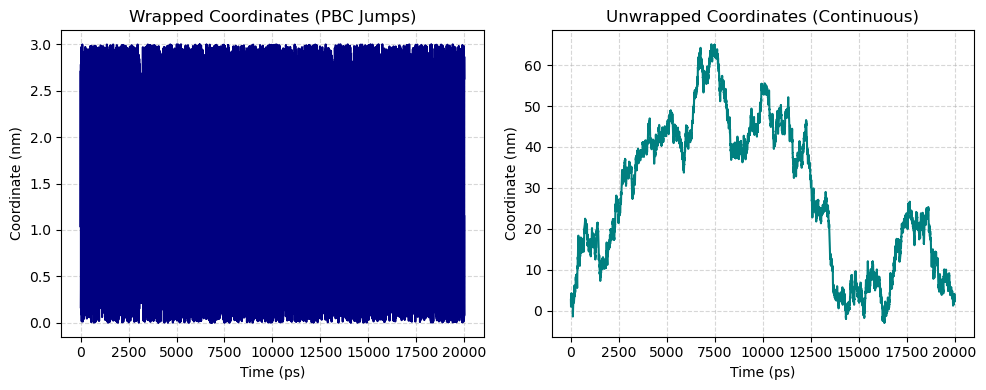

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
time = molsys_wrapped['time']

ax1.plot(time, molsys_wrapped['coordinates'][:, 0, 0], label='Particle 0 (X)', color='navy')
ax1.set_title('Wrapped Coordinates (PBC Jumps)')
ax1.set_xlabel('Time (ps)')
ax1.set_ylabel('Coordinate (nm)')
ax1.grid(True, linestyle='--', alpha=0.5)

ax2.plot(time, molsys_unwrapped['coordinates'][:, 0, 0], label='Particle 0 (X)', color='teal')
ax2.set_title('Unwrapped Coordinates (Continuous)')
ax2.set_xlabel('Time (ps)')
ax2.set_ylabel('Coordinate (nm)')
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


:::{seealso} Related Tools & References
:class: dropdown

- {ref}`Convert <Tutorial_Convert>`: Convert molecular systems with {func}`molsysmt.basic.convert`.
- {ref}`Wrap to PBC <Tutorial_Wrap_to_pbc>`: Wrap coordinates to periodic box with {func}`molsysmt.pbc.wrap_to_pbc`.
- {ref}`Wrap to MIC <Tutorial_Wrap_to_mic>`: Wrap to minimum image convention with {func}`molsysmt.pbc.wrap_to_mic`.
:::
